In [62]:
import pandas as pd

In [63]:
df = pd.read_csv(r'..\data\cleaned_train_sample.csv')

In [64]:
# 1) Night time feature
df['is_night_login'] = ((df['hour'] >= 23) | (df['hour'] <= 5)).astype(int)

In [65]:
# 2) High risk country feature
df['is_high_risk_country'] = (df['Country'] == 'RO').astype(int)

In [66]:
# 3) Bot browser feature
target_browser = 'Chrome 79.0.3945.192.218'
df['is_bot_browser'] = (df['Browser Name and Version'] == target_browser).astype(int)

In [67]:
# 4) Attack ASN feature
asns = [62350, 206801, 197175]
df['is_attack_asn'] = (df['ASN'].isin(asns)).astype(int)

In [68]:
df[['is_high_risk_country', 'is_night_login', 'is_bot_browser', 'is_attack_asn']].head()

,is_high_risk_country,is_night_login,is_bot_browser,is_attack_asn
0,0,0,0,0
1,0,1,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
test_cols = [
    'is_high_risk_country',
    'is_night_login',
    'is_attack_asn',
    'is_bot_browser',
    'Is Account Takeover'
]

In [71]:
correlation_matrix = df[test_cols].corr()

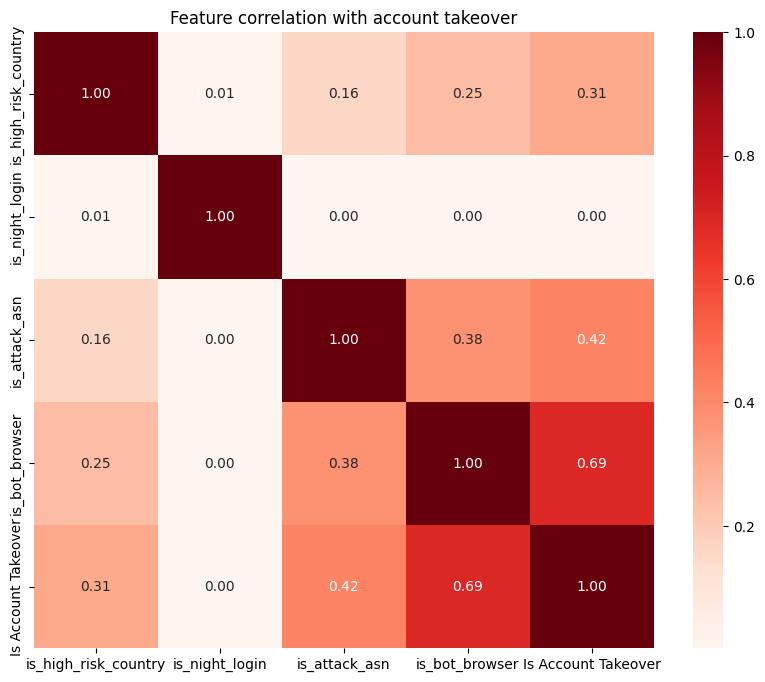

In [72]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='Reds', fmt=".2f")
plt.title("Feature correlation with account takeover")
plt.show()

In [73]:
df.head()

,Login Timestamp,User ID,IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover,hour,is_night_login,is_high_risk_country,is_bot_browser,is_attack_asn
0,2020-03-31 18:22:31.446,-1751455383105469063,31.185.24.172,NO,Viken,Gjerdrum,2116,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.0.0.2416,iOS 7.1,mobile,True,False,False,18,0,0,0,0
1,2020-03-06 02:54:37.898,8397202535583890606,80.211.249.38,PL,Mazovia,Warsaw,205727,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Chrome Mobile 81.0.4044,iOS 13.4,mobile,True,False,False,2,1,0,0,0
2,2020-05-06 08:27:20.512,-4324475583306591935,77.72.57.141,FI,Uusimaa,Helsinki,42252,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Chrome Mobile 81.0.4044.1926,iOS 11.2.6,mobile,False,False,False,8,0,0,0,0
3,2020-02-07 19:00:21.044,6558541938824566943,150.214.0.15,SC,-,-,198096,Mozilla/5.0 (iPhone; CPU iPhone OS 13_1_3 lik...,Chrome Mobile 81.0.4044.2180,iOS 13.1.3,mobile,True,False,False,19,0,0,0,0
4,2020-09-01 09:49:28.481,-4324475583306591935,92.48.79.232,GB,-,-,29550,Mozilla/5.0 (iPad; CPU OS 5_1_1 like Mac OS X...,Android 2.3.3.2660,iOS 5.1.1,mobile,False,False,False,9,0,0,0,0


In [74]:
cols_to_drop = [
    'Login Timestamp', 'User ID', 'IP Address', 'Country', 
    'Region', 'City', 'ASN', 'User Agent String', 
    'Browser Name and Version', 'OS Name and Version', 'hour'
]

In [75]:
df_final = df.drop(columns = cols_to_drop)

In [76]:
df_final.head()

,Device Type,Login Successful,Is Attack IP,Is Account Takeover,is_night_login,is_high_risk_country,is_bot_browser,is_attack_asn
0,mobile,True,False,False,0,0,0,0
1,mobile,True,False,False,1,0,0,0
2,mobile,False,False,False,0,0,0,0
3,mobile,True,False,False,0,0,0,0
4,mobile,False,False,False,0,0,0,0


In [77]:
df_final = pd.get_dummies(df_final, columns=['Device Type'], drop_first=True)

print("Final columns for AI training")
print(df_final.columns)
df_final.head()

Final columns for AI training
Index(['Login Successful', 'Is Attack IP', 'Is Account Takeover',
       'is_night_login', 'is_high_risk_country', 'is_bot_browser',
       'is_attack_asn', 'Device Type_bot', 'Device Type_desktop',
       'Device Type_mobile', 'Device Type_tablet', 'Device Type_unknown'],
      dtype='object')


,Login Successful,Is Attack IP,Is Account Takeover,is_night_login,is_high_risk_country,is_bot_browser,is_attack_asn,Device Type_bot,Device Type_desktop,Device Type_mobile,Device Type_tablet,Device Type_unknown
0,True,False,False,0,0,0,0,False,False,True,False,False
1,True,False,False,1,0,0,0,False,False,True,False,False
2,False,False,False,0,0,0,0,False,False,True,False,False
3,True,False,False,0,0,0,0,False,False,True,False,False
4,False,False,False,0,0,0,0,False,False,True,False,False


In [78]:
df_final.to_csv(r'..\data\final_features.csv', index=False)